## **1. Data Preparation**

### 1.1 Import Libraries

In [1]:
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# SKLearn Library
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics.pairwise import cosine_similarity

### 1.2 Load Dataset

In [2]:
data = pd.read_csv('tmdb_5000_movies.csv')
data.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


### 1.3 Dimensi Data

In [3]:
data.shape

(4803, 20)

### 1.4 Kolom Data

In [4]:
data.columns

Index(['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'vote_average',
       'vote_count'],
      dtype='str')

### 1.5 Tipe Data

In [5]:
data.dtypes

budget                    int64
genres                      str
homepage                    str
id                        int64
keywords                    str
original_language           str
original_title              str
overview                    str
popularity              float64
production_companies        str
production_countries        str
release_date                str
revenue                   int64
runtime                 float64
spoken_languages            str
status                      str
tagline                     str
title                       str
vote_average            float64
vote_count                int64
dtype: object

### 1.6 Membuat Salinan DataFrame

In [6]:
df = data.copy()
df = df[['id', 'title', 'budget', 'genres', 'popularity', 'production_companies', 'revenue', 'vote_average', 'vote_count']]
df.head()

,id,title,budget,genres,popularity,production_companies,revenue,vote_average,vote_count
0,19995,Avatar,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...",2787965087,7.2,11800
1,285,Pirates of the Caribbean: At World's End,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...",961000000,6.9,4500
2,206647,Spectre,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...",880674609,6.3,4466
3,49026,The Dark Knight Rises,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...",1084939099,7.6,9106
4,49529,John Carter,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]",284139100,6.1,2124


### 1.7 Mengecek Nilai Kosong

In [7]:
df.isnull().sum()

id                      0
title                   0
budget                  0
genres                  0
popularity              0
production_companies    0
revenue                 0
vote_average            0
vote_count              0
dtype: int64

### 1.8 Mengecek Nilai Duplikasi

In [8]:
df.duplicated().sum()

np.int64(0)

### 1.9 Memisahkan Id dan Nama untuk Kolom genres dan production_companie

In [9]:
def ekstrak_name(name_str):
  try:
    genres = json.loads(name_str)
    return [genre['name'] for genre in genres]
  except (TypeError, json.JSONDecodeError):
    return None
  
def ekstrak_id(name_str):
  try:
    genres = json.loads(name_str)
    return [genre['id'] for genre in genres]
  except (TypeError, json.JSONDecodeError):
    return None

# mengekstrak id
df['num_genres'] = df['genres'].apply(ekstrak_id)
df['num_production_companies'] = df['production_companies'].apply(ekstrak_id)

# mengekstrak nama
df['genres'] = df['genres'].apply(ekstrak_name)
df['production_companies'] = df['production_companies'].apply(ekstrak_name)

df.head()

,id,title,budget,genres,popularity,production_companies,revenue,vote_average,vote_count,num_genres,num_production_companies
0,19995,Avatar,237000000,"[Action, Adventure, Fantasy, Science Fiction]",150.437577,"[Ingenious Film Partners, Twentieth Century Fo...",2787965087,7.2,11800,"[28, 12, 14, 878]","[289, 306, 444, 574]"
1,285,Pirates of the Caribbean: At World's End,300000000,"[Adventure, Fantasy, Action]",139.082615,"[Walt Disney Pictures, Jerry Bruckheimer Films...",961000000,6.9,4500,"[12, 14, 28]","[2, 130, 19936]"
2,206647,Spectre,245000000,"[Action, Adventure, Crime]",107.376788,"[Columbia Pictures, Danjaq, B24]",880674609,6.3,4466,"[28, 12, 80]","[5, 10761, 69434]"
3,49026,The Dark Knight Rises,250000000,"[Action, Crime, Drama, Thriller]",112.312950,"[Legendary Pictures, Warner Bros., DC Entertai...",1084939099,7.6,9106,"[28, 80, 18, 53]","[923, 6194, 9993, 9996]"
4,49529,John Carter,260000000,"[Action, Adventure, Science Fiction]",43.926995,[Walt Disney Pictures],284139100,6.1,2124,"[28, 12, 878]",[2]


### 1.10 Mengambil Nilai Paling Depan di Kolom genres dan production_companies

In [10]:
df['dominan_genre'] = df['genres'].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else None)
df['dominan_production'] = df['production_companies'].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else None)
df.head()

,id,title,budget,genres,popularity,production_companies,revenue,vote_average,vote_count,num_genres,num_production_companies,dominan_genre,dominan_production
0,19995,Avatar,237000000,"[Action, Adventure, Fantasy, Science Fiction]",150.437577,"[Ingenious Film Partners, Twentieth Century Fo...",2787965087,7.2,11800,"[28, 12, 14, 878]","[289, 306, 444, 574]",Action,Ingenious Film Partners
1,285,Pirates of the Caribbean: At World's End,300000000,"[Adventure, Fantasy, Action]",139.082615,"[Walt Disney Pictures, Jerry Bruckheimer Films...",961000000,6.9,4500,"[12, 14, 28]","[2, 130, 19936]",Adventure,Walt Disney Pictures
2,206647,Spectre,245000000,"[Action, Adventure, Crime]",107.376788,"[Columbia Pictures, Danjaq, B24]",880674609,6.3,4466,"[28, 12, 80]","[5, 10761, 69434]",Action,Columbia Pictures
3,49026,The Dark Knight Rises,250000000,"[Action, Crime, Drama, Thriller]",112.312950,"[Legendary Pictures, Warner Bros., DC Entertai...",1084939099,7.6,9106,"[28, 80, 18, 53]","[923, 6194, 9993, 9996]",Action,Legendary Pictures
4,49529,John Carter,260000000,"[Action, Adventure, Science Fiction]",43.926995,[Walt Disney Pictures],284139100,6.1,2124,"[28, 12, 878]",[2],Action,Walt Disney Pictures


## **2. Exploratory Data Analysis**

### 2.1 Melihat Informasi Data

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        4803 non-null   int64  
 1   title                     4803 non-null   str    
 2   budget                    4803 non-null   int64  
 3   genres                    4803 non-null   object 
 4   popularity                4803 non-null   float64
 5   production_companies      4803 non-null   object 
 6   revenue                   4803 non-null   int64  
 7   vote_average              4803 non-null   float64
 8   vote_count                4803 non-null   int64  
 9   num_genres                4803 non-null   object 
 10  num_production_companies  4803 non-null   object 
 11  dominan_genre             4775 non-null   str    
 12  dominan_production        4452 non-null   str    
dtypes: float64(2), int64(4), object(4), str(3)
memory usage: 487.9+ KB


### 2.2 Melihat 10 Genre Film Teratas

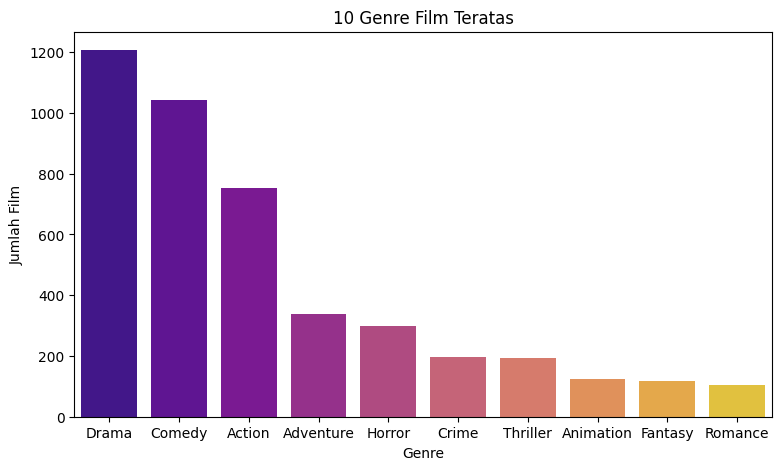

In [12]:
genre_value_counts = df['dominan_genre'].value_counts()
top_ten_genres = genre_value_counts.head(10)

plt.figure(figsize=(9,5))
sns.barplot(x=top_ten_genres.index, y=top_ten_genres.values, hue=top_ten_genres.index, palette='plasma')
plt.title('10 Genre Film Teratas')
plt.ylabel('Jumlah Film')
plt.xlabel('Genre')
plt.show()

### 2.3 Melihat Nilai Tertinggi di Kolom revenue

In [13]:
df.sort_values(by='revenue', ascending=False).head(1)

,id,title,budget,genres,popularity,production_companies,revenue,vote_average,vote_count,num_genres,num_production_companies,dominan_genre,dominan_production
0,19995,Avatar,237000000,"[Action, Adventure, Fantasy, Science Fiction]",150.437577,"[Ingenious Film Partners, Twentieth Century Fo...",2787965087,7.2,11800,"[28, 12, 14, 878]","[289, 306, 444, 574]",Action,Ingenious Film Partners


### 2.4 Melihat Keuntungan dan Kerugian dari Kolom revenue

In [14]:
keuntungan = df['revenue'] - df['budget']
keuntungan.index = df['title']
print('Film yang memiliki keuntungan terbesar: ', keuntungan.idxmax())
print('Film yang memiliki kerugian terbesar: ', keuntungan.idxmin())

Film yang memiliki keuntungan terbesar:  Avatar
Film yang memiliki kerugian terbesar:  The Lone Ranger


### 2.5 Melihat Film Yang Memiliki Voting Terbanyak

In [15]:
film_voting_terbanyak = df.loc[df['vote_count'].idxmax(), 'title']
avg_vote = df.loc[df['vote_count'].idxmax(), 'vote_average']
jumlah_voting = df['vote_count'].max()

print('Film yang memiliki voting terbanyak:', film_voting_terbanyak)
print('Jumlah voting:', jumlah_voting)
print('Rata-rata voting:', avg_vote)

Film yang memiliki voting terbanyak: Inception
Jumlah voting: 13752
Rata-rata voting: 8.1


### 2.6 Melihat Film Yang Memiliki Voting Terendah

In [16]:
film_voting_terendah = df.loc[df['vote_count'].idxmin(), 'title']
avg_vote_min = df.loc[df['vote_count'].idxmin(), 'vote_average']
count_min_voting = df['vote_count'].min()

print('Film yang memiliki voting terendah:', film_voting_terendah)
print('Jumlah voting:', count_min_voting)
print('Rata-rata voting:', avg_vote_min)

Film yang memiliki voting terendah: Black Water Transit
Jumlah voting: 0
Rata-rata voting: 0.0


## **3. Data Preprocessing**

### 3.1 Membuat DataFrame Baru

In [17]:
features = df[['title', 'budget', 'num_genres', 'popularity', 'num_production_companies', 'revenue', 'vote_average', 'vote_count']]
features.head()

,title,budget,num_genres,popularity,num_production_companies,revenue,vote_average,vote_count
0,Avatar,237000000,"[28, 12, 14, 878]",150.437577,"[289, 306, 444, 574]",2787965087,7.2,11800
1,Pirates of the Caribbean: At World's End,300000000,"[12, 14, 28]",139.082615,"[2, 130, 19936]",961000000,6.9,4500
2,Spectre,245000000,"[28, 12, 80]",107.376788,"[5, 10761, 69434]",880674609,6.3,4466
3,The Dark Knight Rises,250000000,"[28, 80, 18, 53]",112.312950,"[923, 6194, 9993, 9996]",1084939099,7.6,9106
4,John Carter,260000000,"[28, 12, 878]",43.926995,[2],284139100,6.1,2124


### 3.2 Mengecek Tipe Data

In [18]:
features.dtypes

title                           str
budget                        int64
num_genres                   object
popularity                  float64
num_production_companies     object
revenue                       int64
vote_average                float64
vote_count                    int64
dtype: object

### 3.3 Mengambil Nilai Terdepan dari Kolom num_genres dan num_production_companies

In [19]:
features.loc[:, 'num_genres'] = features['num_genres'].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else None)
features.loc[:, 'num_production_companies'] = features['num_production_companies'].apply(lambda x: x[0] if isinstance(x, list) and len(x) > 0 else None)
features.isnull().sum()

title                         0
budget                        0
num_genres                   28
popularity                    0
num_production_companies    351
revenue                       0
vote_average                  0
vote_count                    0
dtype: int64

### 3.4 Menghapus Nilai Kosong dan Mengubah Tipe Data

In [20]:
features = features.dropna(axis=0)

features[['num_genres', 'num_production_companies']] = features[['num_genres', 'num_production_companies']].astype('int64')

features.dtypes

title                           str
budget                        int64
num_genres                    int64
popularity                  float64
num_production_companies      int64
revenue                       int64
vote_average                float64
vote_count                    int64
dtype: object

## **4. ...**

### 4.1 Cosine Similarity

4.1.1 Menggunakan SKLearn Library

In [21]:
def get_recommendations_by_features(title, budget=None, num_genres=None, popularity=None, num_production_companies=None, revenue=None, vote_average=None, vote_count=None, n=10):
    features_dict = {
        'budget': budget,
        'num_genres': num_genres,
        'popularity': popularity,
        'num_production_companies': num_production_companies,
        'revenue': revenue,
        'vote_average': vote_average,
        'vote_count': vote_count
    }

    selected_features = [feature for feature, value in features_dict.items() if value == 1]

    if len(selected_features) == 0:
        raise ValueError("Harus ada minimal satu fitur yang dipilih!")

    features_subset = features[selected_features]
    
    features_subset = (features_subset - features_subset.mean()) / features_subset.std()
    
    cosine_sim = cosine_similarity(features_subset)
    sim_df = pd.DataFrame(cosine_sim, index=features['title'], columns=features['title'])

    if title not in sim_df.index:
        raise ValueError(f"Film '{title}' tidak ditemukan dalam dataset.")
    
    similar_scores = sim_df[title].sort_values(ascending=False)
    recommendations = similar_scores.index[1:n+1]
    
    return recommendations


In [22]:
recom_film = get_recommendations_by_features('Avatar', vote_average=1, num_genres=1, num_production_companies=1)
print(recom_film)

Index(['The Longest Day', 'Taken', 'The Omen', 'Eddie the Eagle',
       'The Damned United', 'Frances Ha', 'The Reader', 'White Oleander',
       'The Butler', 'Black Book'],
      dtype='str', name='title')


4.1.2 Tanpa SkLearn Library

In [23]:
def get_cosine_similarity(df):
    dot_product = np.dot(df, df.T)

    norms = np.linalg.norm(df, axis=1)
    
    norms = np.where(norms == 0, 1, norms)

    norms_matrix = np.outer(norms, norms)

    cosine_sim_matrix = dot_product / norms_matrix
    return cosine_sim_matrix

In [24]:
def get_recom_manual(title, budget=None, num_genres=None, popularity=None, num_production_companies=None, revenue=None, vote_average=None, vote_count=None, n=10):
    features_dict = {
        'budget': budget,
        'num_genres': num_genres,
        'popularity': popularity,
        'num_production_companies': num_production_companies,
        'revenue': revenue,
        'vote_average': vote_average,
        'vote_count': vote_count
    }

    selected_features = [feature for feature, value in features_dict.items() if value == 1]

    if len(selected_features) == 0:
        raise ValueError("Harus ada minimal satu fitur yang dipilih!")

    features_subset = features[selected_features]
    
    features_subset = (features_subset - features_subset.mean()) / features_subset.std()
    
    cosine_sim = get_cosine_similarity(features_subset)
    sim_df = pd.DataFrame(cosine_sim, index=features['title'], columns=features['title'])

    if title not in sim_df.index:
        raise ValueError(f"Film '{title}' tidak ditemukan dalam dataset.")
    
    similar_scores = sim_df[title].sort_values(ascending=False)
    recom = similar_scores.index[1:n+1]
    
    return recom


In [25]:
recom_film2 = get_recom_manual('Avatar', vote_average=1, budget=1, num_genres=1)
print(recom_film2)

Index(['Monsters University', 'Pirates of the Caribbean: Dead Man's Chest',
       'Tangled', 'Avengers: Age of Ultron', 'Troy',
       'Harry Potter and the Half-Blood Prince', 'Skyfall',
       'Captain America: Civil War',
       'The Hobbit: The Battle of the Five Armies', 'Maleficent'],
      dtype='str', name='title')


### 4.2 Euclidian Distance

In [26]:
def euclidean_distance(vec1, vec2):
  return np.sqrt(np.sum((vec1 - vec2) **2))

In [27]:
def get_euclidian_recom(movie_title, budget=None, num_genres=None, popularity=None, num_production_companies=None, revenue=None, vote_average=None, vote_count=None, n=10):
  features_dict = {
        'budget': budget,
        'num_genres': num_genres,
        'popularity': popularity,
        'num_production_companies': num_production_companies,
        'revenue': revenue,
        'vote_average': vote_average,
        'vote_count': vote_count
    }
  
  selected_features = [feature for feature, value in features_dict.items() if value == 1]

  if len(selected_features) == 0:
      raise ValueError("Harus ada minimal satu fitur yang dipilih!")
    
  features_subset = features[selected_features]
    
  features_subset = (features_subset - features_subset.mean()) / features_subset.std()
  
  selected_movie_features = features_subset[features['title'] == movie_title]
  
  if selected_movie_features.empty:
      raise ValueError(f"Film dengan judul '{movie_title}' tidak ditemukan.")
    
  selected_movie_features = selected_movie_features.values[0]
   
  distances = []
  for i in range(len(features_subset)):
      distance = euclidean_distance(selected_movie_features, features_subset.iloc[i].values)
      distances.append((features['title'].iloc[i], distance))

  distances = sorted(distances, key=lambda x: x[1])

  recommendations = [title for title, dist in distances if title != movie_title][:n]
  
  return recommendations

In [28]:
recom_film3 = get_euclidian_recom('Avatar', vote_average=1, budget=1, num_genres=1)
print(np.array(recom_film3))

['The Hobbit: The Battle of the Five Armies' 'Captain America: Civil War'
 'Harry Potter and the Half-Blood Prince'
 'The Hobbit: An Unexpected Journey' 'X-Men: Days of Future Past'
 'The Dark Knight Rises' 'The Hobbit: The Desolation of Smaug'
 'The Avengers' 'Tangled' 'Man of Steel']


### 4.4 Menghitung Persamaan Rekomendasi Film dari 2 Teknik Berbeda

In [29]:
cosine_movie = set(recom_film2)
euclidean_movie = set(recom_film3)

count_common_movie = len(cosine_movie.intersection(euclidean_movie))
print('Jumlah judul film yang sama:', count_common_movie)

Jumlah judul film yang sama: 4


## **5. GUI**

In [30]:
import tkinter as tk
from tkinter import messagebox

In [31]:
def recommend():
    title = title_entry.get()
    budget = budget_var.get()
    num_genres = genres_var.get()
    popularity = popularity_var.get()
    num_production_companies = companies_var.get()
    revenue = revenue_var.get()
    vote_average = vote_var.get()
    vote_count = count_var.get()

    print(f"Budget: {budget}, Genres: {num_genres}, Popularity: {popularity}, Companies: {num_production_companies}, Revenue: {revenue}, Vote Avg: {vote_average}, Vote Count: {vote_count}")
    

    try:
        recommendations =  get_recom_manual(title, budget, num_genres, popularity, num_production_companies, revenue, vote_average, vote_count)
        recommendations_numbered = "\n".join([f"{i+1}. {rec}" for i, rec in enumerate(recommendations)])
        messagebox.showinfo("Rekomendasi", "Rekomendasi Film:\n" + recommendations_numbered)

    except ValueError as e:
        messagebox.showerror("Error", str(e))


In [32]:
root = tk.Tk()
root.title("Sistem Rekomendasi Film")

budget_var = tk.IntVar()
genres_var = tk.IntVar()
popularity_var = tk.IntVar()
companies_var = tk.IntVar()
revenue_var = tk.IntVar()
vote_var = tk.IntVar()
count_var = tk.IntVar()

# Judul aplikasi
judul_label = tk.Label(root, text="Rekomendasi Film", font=("Arial", 24))
judul_label.pack(pady=20)

# Input judul film
judul_frame = tk.Frame(root)
judul_label = tk.Label(judul_frame, text="Judul Film:")
judul_label.pack(side=tk.LEFT)
title_entry = tk.Entry(judul_frame, width=50)
title_entry.pack(side=tk.LEFT, padx=10)
judul_frame.pack(pady=10)

fitur_frame = tk.Frame(root)
fitur_frame.pack(pady=10)

bagian_kiri = tk.Frame(fitur_frame)
bagian_kiri.pack(side=tk.LEFT, padx=10)

tk.Checkbutton(bagian_kiri, text="Anggaran", variable=budget_var).pack(anchor=tk.W)
tk.Checkbutton(bagian_kiri, text="Genre", variable=genres_var).pack(anchor=tk.W)
tk.Checkbutton(bagian_kiri, text="Popularitas", variable=popularity_var).pack(anchor=tk.W)
tk.Checkbutton(bagian_kiri, text="Perusahaan Produksi", variable=companies_var).pack(anchor=tk.W)

bagian_kanan = tk.Frame(fitur_frame)
bagian_kanan.pack(side=tk.LEFT, padx=10)

tk.Checkbutton(bagian_kanan, text="Pendapatan", variable=revenue_var).pack(anchor=tk.W)
tk.Checkbutton(bagian_kanan, text="Rata-rata Voting", variable=vote_var).pack(anchor=tk.W)
tk.Checkbutton(bagian_kanan, text="Total Voting", variable=count_var).pack(anchor=tk.W)

tk.Button(root, text="Dapatkan Rekomendasi", command=recommend).pack(pady=10)
root.mainloop()